<a href="https://colab.research.google.com/github/thamirisbalbi/AnaliseDados/blob/main/%5BTemplate%5D_aulaCelulasT(2).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Descrição do modelo da aula prática de hoje

Vamos estudar um modelo matemático bem simples composto por duas equações diferenciais ordinárias para representar as dinâmicas de expansao das células T a partir da presença do complexo formado por antígeno (peptideo) + MHC. Chamaremos esse complexo de pMHC.

Com base no Modelo resumido do livro texto [1] e nas EDOs utilizadas na referência [2], vamos considerar que:

- a expansão das células T deve ser cuidadosamente regulada para garantir uma resposta eficiente;
- o número de celulas T naive é enviesado pelo maquinário de recombinação e seleção no Timo; VDJ -> Variable Diversity Joining
- o numero total de células T específicas a um antigeno depende de infeccoes anteriores.
- há grande variação no número de células no momento anterior a resposta, depende de vários fatores;
    - como o sistema adaptativo regula a expansão de linfócitos dado esses números precursores variáveis?
    
Para representar as dinâmicas de células T e complexo pMHC observamos que naturalmente surge uma relação de potências entre elas -> a proliferação é limitada por disponibilidade de antigenos.

- a referencia [2] busca prever como o expoente se relaciona às taxas de proliferacao, morte e decaimento de antígenos. Vamos tentar reproduzir e extender essas analises nessa aula.

\begin{align}
&\frac{d T}{dt} = \frac{\alpha C T}{(K+T+C)} - \delta T, T(0) = T_0 \\
&\frac{d C}{dt} = - \mu C, C(0) = C_0  
\end{align}

As equações representam as células T ($T$) e os complexos formados por peptídeo+MHC (C).


In [2]:
# importa bibliotecas necessarias
import matplotlib.pyplot as plt
import numpy as np

# define uma funcao feval que recebe o nome da equacao a ser avaliada como string
# e retorna a funcao a ser avaliada
def feval(funcName, *args):
    return eval(funcName)(*args)

# Obs: eval faz parte da biblioteca padrao do python
# outros exemplos no link: https://www.programiz.com/python-programming/methods/built-in/eval

In [3]:
# define a resolucao numerica por runge-kutta de quarta ordem
def RK4thOrder(func, yinit, x_range, h):
    m = len(yinit)
    n = int((x_range[-1] - x_range[0])/h)

    x = x_range[0]
    y = yinit

    # Containers for solutions
    xsol = np.empty(0)
    xsol = np.append(xsol, x)

    ysol = np.empty(0)
    ysol = np.append(ysol, y)

    for i in range(n):
        k1 = feval(func, x, y)

        yp2 = y + k1*(h/2)

        k2 = feval(func, x+h/2, yp2)

        yp3 = y + k2*(h/2)

        k3 = feval(func, x+h/2, yp3)

        yp4 = y + k3*h

        k4 = feval(func, x+h, yp4)

        for j in range(m):
            y[j] = y[j] + (h/6)*(k1[j] + 2*k2[j] + 2*k3[j] + k4[j])

        x = x + h
        xsol = np.append(xsol, x)

        for r in range(len(y)):
            ysol = np.append(ysol, y[r])

    return [xsol, ysol]

In [4]:
# define a funcao que contem as equacoes do sistema a ser avaliado
def celulasT(x, y):
    ## parametros do sistema de 3 equacoes descrito acima
    alpha = 1.2  # proliferacao
    delta = 0.0 # 22
    mu    = 1.1
    K     = 10
    v0 = 2*10**6

    ## inicializa com zeros
    dy = np.zeros(2)

    T = y[0]
    C = y[1]

    def v(x):
      if x < 4:
          return v0
      else:
          return 0

    dy[0] = (alpha*T*C)/(K+C+T) - delta*T
    dy[1] =  -mu*C

    return dy

In [5]:
# define os parametros da solucao numerica

# passo
h = 0.01

#
x = np.array([0.0, 10.0])

# condicoes iniciais
T0 = 300.0
C0 = 10e6

yinit = np.array([T0,C0], dtype='f')

# chama o metodo de runge-kutta definido anteriormente
#passando o nome da funcao como parametro
# alem da condicao inicial, vetor contendo os valores para os
#quais a funcao deve ser avaliada e o passo
[ts, ys] = RK4thOrder('celulasT', yinit, x, h)

# prepara o resultado para visualizacao
node = len(yinit)
T300 = ys[0::node]
C = ys[1::node]

In [ ]:
# No artigo sao apresentados dois valores iniciais distintos
# para Celula T portanto rodaremos separadamente:

# condicoes iniciais
T0 = 30000.0
C0 = 10e6

yinit = np.array([T0,C0], dtype='f')
[ts, ys] = RK4thOrder('celulasT', yinit, x, h)


In [6]:
# prepara o resultado para visualizacao
node = len(yinit)
T30K = ys[0::node]

# Obs a variavel C é independende do T entao
# nao precisa salvar novamente

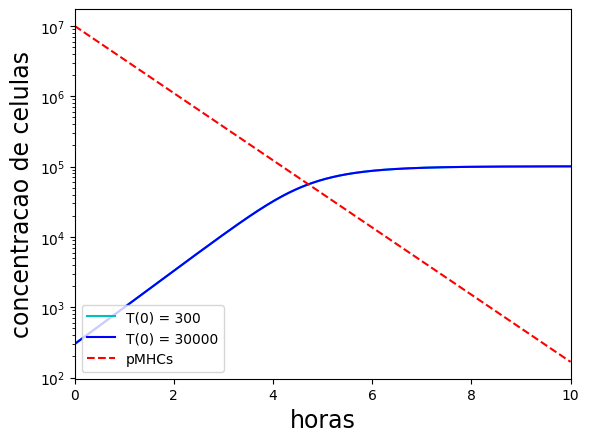

In [7]:
plt.plot(ts, T300, 'c')
plt.plot(ts, T30K, 'b')
plt.plot(ts, C, 'r--')


plt.xlim(x[0], x[1])
plt.legend(["T(0) = 300", "T(0) = 30000", "pMHCs"], loc=3)
plt.xlabel('horas', fontsize=17)
plt.ylabel('concentracao de celulas', fontsize=17)
plt.yscale('log')
plt.show()

### Observações:

- Quando antígeno é abundante todas as células T específicas recebem estímulo suficiente para proliferar a taxa máxima
- Quando o número de células T é grande em relação ao número de antígenos a taxa de proliferação é proporcional à C porque antígeno se torna limitante.

### Atividades:

1. Teste o modelo apresentado e confira com a figura 1C da referencia [2].

2. Varie os valores de K conforme discutido nos experimentos (Fig 3) da referencia [2] e verifique se consegue replicar os resultados apresentados. O que significa esse parâmetro K e qual a influência sobre a variação da expansao das células T?   



3. Para observar a relevancia dos antigenos (Fig 4) adicione um termo dependente de tempo v(t) para fonte de antigenos conforme explicado na pagina 5917 (veja tambem a Eq. 8). Teste diferentes valores conforme mostrado na Figura 4.

___

[1] Sompayrac, L. How the immune system works. 3rd ed. Blackwell Publishing.2008.

[2] Mayer et al, Regulation of T cell expansion by antigen
presentation dynamics. PNAS. v 116. p 5914-5919 www.pnas.org/cgi/doi/10.1073/pnas.1812800116. 2019.